<a href="https://colab.research.google.com/github/balaabirami72-sys/Boston-House-Price-Prediction-using-Regression/blob/main/Heart_disease_predictor_using_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving heart_disease_risk_score.csv to heart_disease_risk_score.csv
Dataset Loaded Successfully!

Accuracy: 0.8039


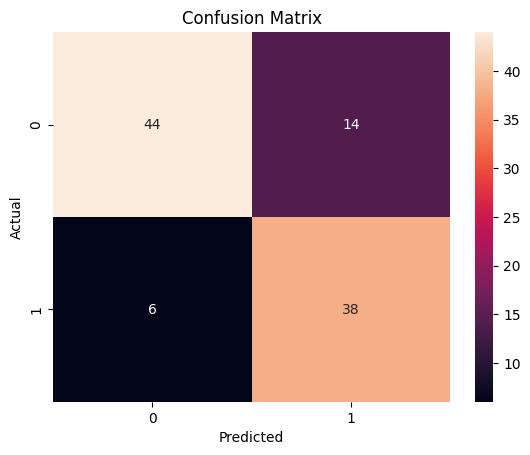

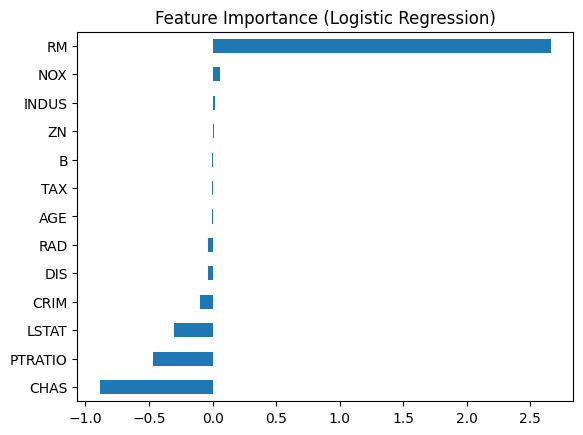


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.76      0.81        58
           1       0.73      0.86      0.79        44

    accuracy                           0.80       102
   macro avg       0.81      0.81      0.80       102
weighted avg       0.82      0.80      0.80       102



In [3]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("Schedly_Boston_Housing_Unique.csv")

print("Dataset Loaded Successfully!\n")

# Handle missing values
threshold = 0.6 * len(df)
df = df.dropna(thresh=threshold, axis=1)
df.fillna(df.mean(numeric_only=True), inplace=True)

# One-hot encode categorical features
# The original dataset 'Schedly_Boston_Housing_Unique.csv' does not contain 'Smoking_Status' or 'Family_History'.
# This line has been removed as these columns are not present.

# Convert continuous Risk_Score to a binary categorical target for classification
# Assuming 'Risk_Score' is intended to be 'MEDV' (median value of owner-occupied homes) for the Boston Housing dataset.
# If a 'Risk_Score' column truly existed and was intended, this logic would apply to it.
# For now, converting 'MEDV' to a binary target based on its median.
median_medv = df['MEDV'].median()
df['Risk_Category'] = np.where(df['MEDV'] > median_medv, 1, 0)

# Set target to the new categorical column
target = "Risk_Category"

X = df.drop(["MEDV", target], axis=1) # Drop original 'MEDV' and new target from features
y = df[target]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
model = LogisticRegression(max_iter=5000) # Increased max_iter to help convergence
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy,4))

# ---------------- CONFUSION MATRIX GRAPH ----------------
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------- FEATURE IMPORTANCE GRAPH ----------------
coefficients = pd.Series(model.coef_[0], index=X.columns)
coefficients.sort_values().plot(kind='barh')
plt.title("Feature Importance (Logistic Regression)")
plt.show()

# ---------------- CLASSIFICATION REPORT ----------------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))